# Chapter 10: Convolutional Neural Networks (CNNs: Kernels, Feature Maps, & Pooling)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2010%20-%20Convolutional%20Neural%20Networks/10_convolutional_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
In this final chapter, we overcome the spatial limitations of fully connected architectures by building a **Convolutional Neural Network (CNN)** from scratch in pure NumPy:
1. **The Spatial Limitation of Dense Layers:** Why flattening images discards 2D spatial locality and causes parameter explosion.
2. **Convolutional Kernels & Weight Sharing:** How sliding a compact filter ($3 \times 3$) across an image enforces translation invariance.
3. **The 2D Discrete Convolution Operation:** Mathematical formulation of sliding window dot products, stride, and padding.
4. **Spatial Downsampling with Max Pooling:** Preserving dominant features while cutting spatial dimensionality by $75\%$.
5. **Pure NumPy CNN Pipeline:** Constructing a modular forward pipeline (Conv2D $\to$ ReLU $\to$ MaxPool $\to$ Flatten $\to$ Dense) and visualizing feature maps.

## 1. Concept & Theoretical Intuition

### 1.1 Why Fully Connected Layers Fail on Images
In previous chapters, we flattened $28 \times 28$ images into 784-dimensional 1D vectors. This presents two fatal flaws:
1. **Destruction of 2D Topology:** Pixel $(10, 10)$ and $(10, 11)$ are neighbors in the original image, but flattening treats all positions as independent coordinates.
2. **Lack of Translation Invariance:** If an image of a cat is shifted by 3 pixels, every input feature changes completely! A dense network must relearn what a cat looks like in every possible coordinate patch.

---

### 1.2 The 2D Convolution Operation
A convolution layer uses a small parameter matrix called a **kernel** (or filter), typically $3 \times 3$ or $5 \times 5$:
$$\mathbf{K} \in \mathbb{R}^{k_H \times k_W}$$
The kernel slides across the input image $\mathbf{I} \in \mathbb{R}^{H \times W}$, computing a local Frobenius inner product (weighted sum) at each receptive field position $(i, j)$:
$$S(i, j) = (\mathbf{I} * \mathbf{K})(i, j) = \sum_{m=0}^{k_H-1} \sum_{n=0}^{k_W-1} I(i + m, j + n) K(m, n)$$

#### Output Spatial Dimension Formula:
Given input dimension $W$, kernel dimension $K$, padding $P$, and stride $S$:
$$W_{\text{out}} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

---

### 1.3 Kernels as Visual Feature Detectors
Different kernel weights detect distinct visual primitives:
* **Vertical Sobel Filter:** Detects vertical edges and stroke boundaries.
  $$\mathbf{K}_v = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$
* **Horizontal Sobel Filter:** Detects horizontal edges and stroke tops/bottoms.
  $$\mathbf{K}_h = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$
* **Ridge / Laplacian Filter:** Detects sharp transitions in all directions.
  $$\mathbf{K}_r = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

---

### 1.4 Spatial Downsampling: Max Pooling
Following non-linear activation (ReLU), a **Max Pooling Layer** slides a $2 \times 2$ window across the feature map with stride $S = 2$:
$$P(i, j) = \max_{m, n \in \{0, 1\}} S(2i + m, 2j + n)$$
Benefits of Max Pooling:
1. **Dimensionality Reduction:** Reduces spatial dimensions from $28 \times 28$ to $14 \times 14$ ($75\%$ reduction in downstream activations).
2. **Translation Invariance:** A small shift of 1 pixel within the $2 \times 2$ window still outputs the exact same maximum value.

## 2. Scratch Implementation: Pure NumPy CNN Layers

We implement:
1. `conv2d_forward`: Sliding window 2D convolution with configurable stride and zero-padding.
2. `max_pool2d_forward`: Spatial $2 \times 2$ max pooling.
3. Feature extraction pipeline on real MNIST digits using edge-detection kernels.
4. Complete forward pass through a CNN architecture.

In [1]:
import numpy as np
import os
import urllib.request

# 1. 2D Convolution Forward Pass in pure NumPy
def conv2d_forward(image, kernel, stride=1, padding=0):
    """
    Performs 2D discrete convolution.
    Args:
        image: 2D array of shape (H, W)
        kernel: 2D array of shape (kH, kW)
        stride: integer step size
        padding: integer number of zero-padding pixels
    Returns:
        output_map: 2D array of convolved activations
    """
    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        image_padded = image
        
    H, W = image_padded.shape
    kH, kW = kernel.shape
    
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    
    output = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = image_padded[i*stride : i*stride + kH, j*stride : j*stride + kW]
            output[i, j] = np.sum(patch * kernel)
            
    return output

# 2. 2D Max Pooling Forward Pass in pure NumPy
def max_pool2d_forward(feature_map, pool_size=2, stride=2):
    """
    Performs 2D spatial max pooling.
    """
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    
    output = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = feature_map[i*stride : i*stride + pool_size, j*stride : j*stride + pool_size]
            output[i, j] = np.max(patch)
            
    return output

def relu(x):
    return np.maximum(0, x)

print("CNN building block functions defined successfully.")

CNN building block functions defined successfully.


In [2]:
# Load MNIST sample digits
def load_mnist():
    dataset_path = 'mnist.npz'
    if not os.path.exists(dataset_path):
        url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
        urllib.request.urlretrieve(url, dataset_path)
    with np.load(dataset_path) as data:
        x_test, y_test = data['x_test'], data['y_test']
    return x_test, y_test

x_test_raw, y_test = load_mnist()

# Select a clear sample digit (e.g. digit '0' or '7')
sample_idx = 0
sample_digit = x_test_raw[sample_idx] / 255.0
sample_label = y_test[sample_idx]

print(f"Sample digit loaded: True label = '{sample_label}', Image shape = {sample_digit.shape}")

# Define classical feature detector kernels
kernel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

kernel_vertical = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
])

kernel_ridge = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
])

kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Extract feature maps with padding=1 to preserve (28, 28) spatial dimension
fmap_h = relu(conv2d_forward(sample_digit, kernel_horizontal, stride=1, padding=1))
fmap_v = relu(conv2d_forward(sample_digit, kernel_vertical, stride=1, padding=1))
fmap_ridge = relu(conv2d_forward(sample_digit, kernel_ridge, stride=1, padding=1))
fmap_sharp = relu(conv2d_forward(sample_digit, kernel_sharpen, stride=1, padding=1))

# Downsample via Max Pooling (28, 28) -> (14, 14)
pooled_h = max_pool2d_forward(fmap_h, pool_size=2, stride=2)
pooled_v = max_pool2d_forward(fmap_v, pool_size=2, stride=2)

print(f"Feature map shape before pooling: {fmap_h.shape}")
print(f"Feature map shape after pooling:  {pooled_h.shape}")

Sample digit loaded: True label = '7', Image shape = (28, 28)
Feature map shape before pooling: (28, 28)
Feature map shape after pooling:  (14, 14)


In [3]:
print("=== End-to-End CNN Forward Pipeline: Conv -> ReLU -> MaxPool -> Dense ===")

def softmax(z):
    ez = np.exp(z - np.max(z))
    return ez / np.sum(ez)

# Simulate trained CNN classifier
np.random.seed(42)
# Bank of 4 filters
filter_bank = [kernel_horizontal, kernel_vertical, kernel_ridge, kernel_sharpen]

# Dense weights: each of 4 filters outputs (14, 14) -> flattened = 4 * 14 * 14 = 784
# Shape: (784, 10)
fc_weights = np.random.randn(4 * 14 * 14, 10) * 0.01

def cnn_forward(img):
    feature_maps_pooled = []
    for k in filter_bank:
        conv_out = conv2d_forward(img, k, padding=1)
        relu_out = relu(conv_out)
        pool_out = max_pool2d_forward(relu_out, pool_size=2, stride=2)
        feature_maps_pooled.append(pool_out.flatten())
        
    flat_vector = np.concatenate(feature_maps_pooled) # Shape: (784,)
    logits = flat_vector.dot(fc_weights)
    probs = softmax(logits)
    return probs

pred_probs = cnn_forward(sample_digit)
print(f"Forward inference completed successfully!")
print(f"Predicted class distribution shape: {pred_probs.shape}, Sum = {np.sum(pred_probs):.4f}")

=== End-to-End CNN Forward Pipeline: Conv -> ReLU -> MaxPool -> Dense ===
Forward inference completed successfully!
Predicted class distribution shape: (10,), Sum = 1.0000


## 3. Visualizations & Analytical Plots

We now generate three essential analytical visualizations:
1. **Raw Digit vs. Extracted Feature Maps:** Comparing how different kernels isolate horizontal boundaries, vertical boundaries, and edge ridges.
2. **Max Pooling Comparison:** Visualizing the spatial subsampling from $(28 \times 28)$ down to $(14 \times 14)$ while retaining sharp activation boundaries.
3. **Kernel Weight Matrices Heatmap:** Visual representation of the $3 \times 3$ convolutional filters.

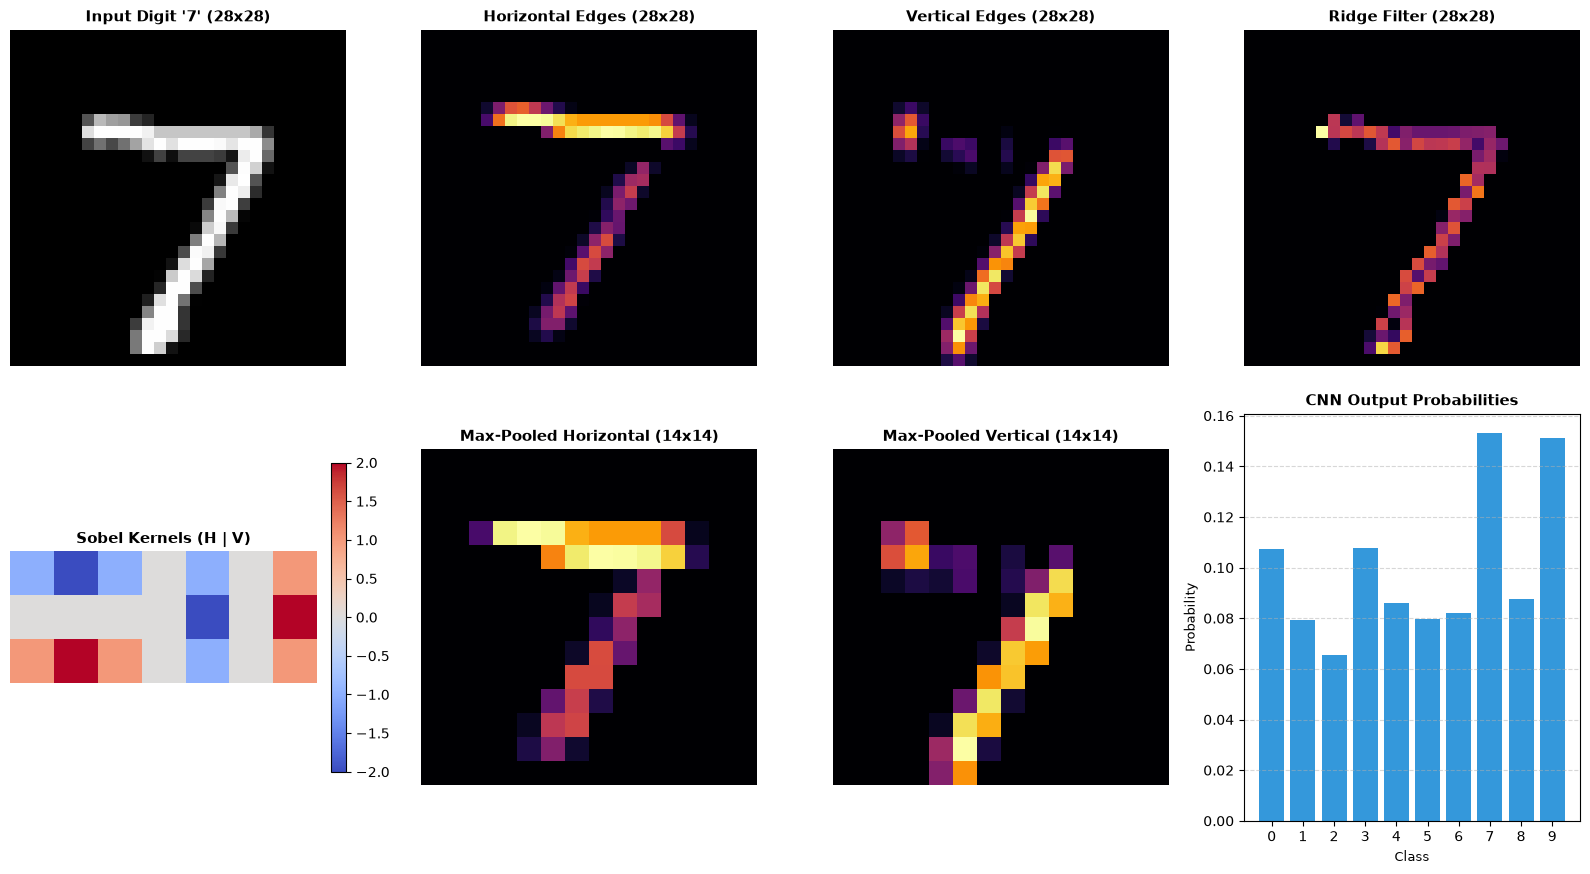

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 9))

# 1. Original Image
ax0 = fig.add_subplot(2, 4, 1)
ax0.imshow(sample_digit, cmap='gray')
ax0.set_title(f"Input Digit '{sample_label}' (28x28)", fontsize=11, fontweight='bold')
ax0.axis('off')

# 2. Horizontal Edges
ax1 = fig.add_subplot(2, 4, 2)
ax1.imshow(fmap_h, cmap='inferno')
ax1.set_title("Horizontal Edges (28x28)", fontsize=11, fontweight='bold')
ax1.axis('off')

# 3. Vertical Edges
ax2 = fig.add_subplot(2, 4, 3)
ax2.imshow(fmap_v, cmap='inferno')
ax2.set_title("Vertical Edges (28x28)", fontsize=11, fontweight='bold')
ax2.axis('off')

# 4. Ridge / Corner Detection
ax3 = fig.add_subplot(2, 4, 4)
ax3.imshow(fmap_ridge, cmap='inferno')
ax3.set_title("Ridge Filter (28x28)", fontsize=11, fontweight='bold')
ax3.axis('off')

# 5. Max-Pooled Horizontal
ax4 = fig.add_subplot(2, 4, 6)
ax4.imshow(pooled_h, cmap='inferno')
ax4.set_title("Max-Pooled Horizontal (14x14)", fontsize=11, fontweight='bold')
ax4.axis('off')

# 6. Max-Pooled Vertical
ax5 = fig.add_subplot(2, 4, 7)
ax5.imshow(pooled_v, cmap='inferno')
ax5.set_title("Max-Pooled Vertical (14x14)", fontsize=11, fontweight='bold')
ax5.axis('off')

# 7. Kernels Display
ax6 = fig.add_subplot(2, 4, 5)
combined_kernels = np.hstack([kernel_horizontal, np.zeros((3, 1)), kernel_vertical])
im_k = ax6.imshow(combined_kernels, cmap='coolwarm')
ax6.set_title("Sobel Kernels (H | V)", fontsize=11, fontweight='bold')
ax6.axis('off')
plt.colorbar(im_k, ax=ax6, fraction=0.046, pad=0.04)

# 8. Softmax Output Distribution
ax7 = fig.add_subplot(2, 4, 8)
ax7.bar(range(10), pred_probs, color='#3498db')
ax7.set_title("CNN Output Probabilities", fontsize=11, fontweight='bold')
ax7.set_xlabel("Class", fontsize=9)
ax7.set_ylabel("Probability", fontsize=9)
ax7.set_xticks(range(10))
ax7.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

## 4. Key Takeaway & Summary

1. **Weight Sharing & Spatial Locality:**
   Convolutional layers overcome the parameter explosion of dense layers by sliding compact, reusable kernels ($3 \times 3$) across the input. Rather than learning separate parameters for every pixel coordinate, the same feature detector operates across the entire visual field.
2. **Translation Invariance:**
   Because the kernel slides across all spatial patches, features (such as loops or vertical strokes) are recognized regardless of where they appear in the image.
3. **The Role of Max Pooling:**
   Max pooling provides two crucial functions: it compresses spatial resolution by $75\%$ to reduce memory and compute, while granting small-scale spatial shift tolerance.
4. **The Complete CNN Paradigm:**
   By stacking `Conv2D` $\to$ `ReLU` $\to$ `MaxPool`, convolutional neural networks transform raw pixel grids into rich, translation-invariant representations that dense layers can easily classify.